In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.utils import load_full_config
from src.model import SimpleTransformer

In [25]:
# Load data and extract consecutive pairs
checkpoint = torch.load('../data/ou_dataset.pt')
X = checkpoint['X']

# Extract (X_t, X_{t+1}) pairs for ground truth
X_t_list = []
X_t1_list = []
num_samples = min(1000, len(X))
for i in range(num_samples):
    seq = X[i].squeeze().numpy()
    X_t_list.extend(seq[:-1])
    X_t1_list.extend(seq[1:])

X_t = np.array(X_t_list)
X_t1_true = np.array(X_t1_list)


In [26]:
# Load model and get predictions
cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleTransformer(**cfg['architecture'])

model_path = os.path.join('..', cfg['paths']['save_dir'], cfg['paths']['model_save_name'])
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
else:
    raise FileNotFoundError(f"Model not found at {model_path}. Please train first.")

# Get model predictions for the same sequences
X_t_pred_list = []
X_t1_pred_list = []

with torch.no_grad():
    for i in range(num_samples):
        seq = X[i:i+1].to(device)  # Shape: (1, 100, 1)
        pred, _ = model(seq)  # Shape: (1, 100, 1)
        pred_np = pred.squeeze().cpu().numpy()
        seq_np = seq.squeeze().cpu().numpy()
        X_t_pred_list.extend(seq_np[:-1])
        X_t1_pred_list.extend(pred_np[:-1])  # pred[t] predicts X[t+1]

X_t_pred = np.array(X_t_pred_list)
X_t1_pred = np.array(X_t1_pred_list)


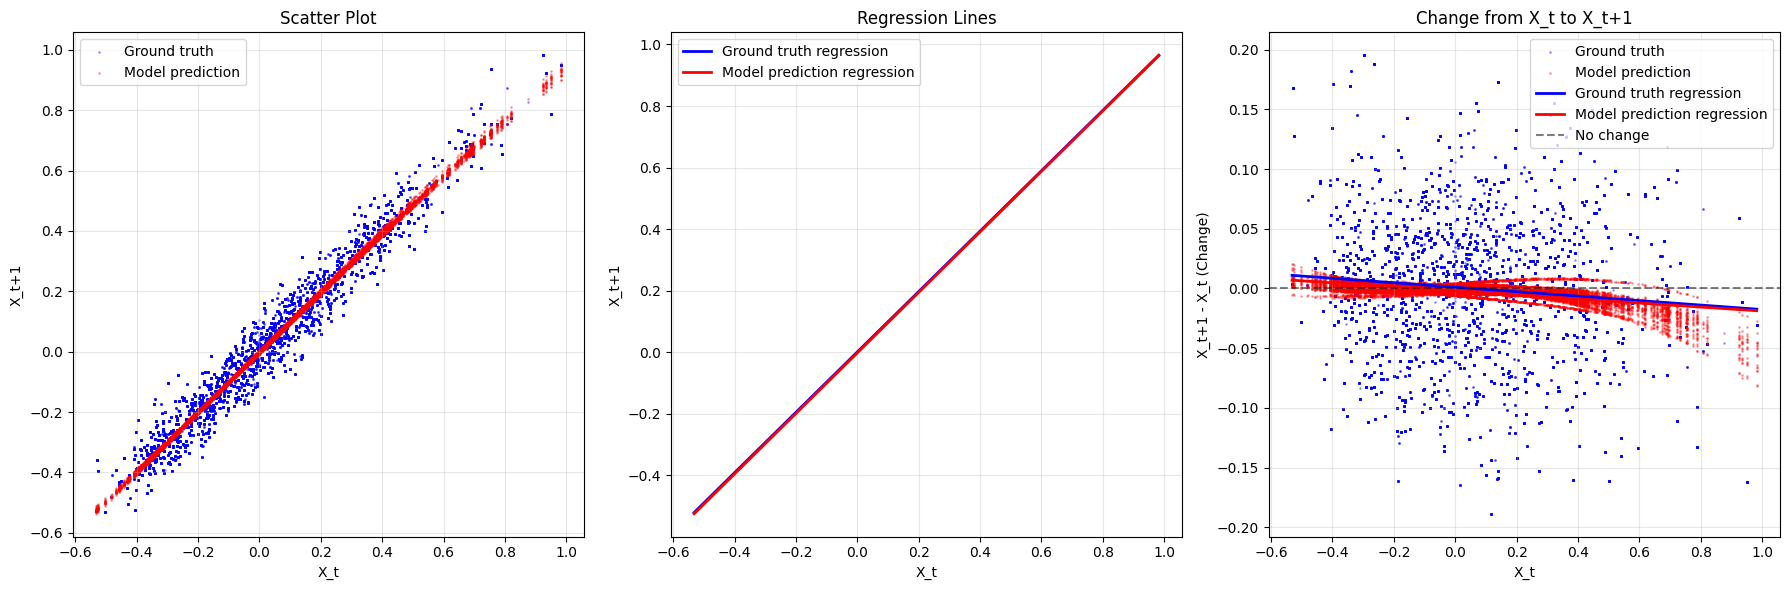

In [27]:
# Fit regression lines
slope_true, intercept_true = np.polyfit(X_t, X_t1_true, 1)
slope_pred, intercept_pred = np.polyfit(X_t_pred, X_t1_pred, 1)

X_t_line = np.linspace(X_t.min(), X_t.max(), 100)
X_t1_line_true = slope_true * X_t_line + intercept_true
X_t1_line_pred = slope_pred * X_t_line + intercept_pred

# Calculate differences from X_t
diff_true = X_t1_true - X_t
diff_pred = X_t1_pred - X_t_pred
diff_line_true = X_t1_line_true - X_t_line
diff_line_pred = X_t1_line_pred - X_t_line

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Scatter plot
axes[0].scatter(X_t, X_t1_true, alpha=0.3, s=1, color='blue', label='Ground truth')
axes[0].scatter(X_t_pred, X_t1_pred, alpha=0.3, s=1, color='red', label='Model prediction')
axes[0].set_xlabel('X_t')
axes[0].set_ylabel('X_t+1')
axes[0].set_title('Scatter Plot')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Regression lines
axes[1].plot(X_t_line, X_t1_line_true, 'b-', linewidth=2, label='Ground truth regression')
axes[1].plot(X_t_line, X_t1_line_pred, 'r-', linewidth=2, label='Model prediction regression')
axes[1].set_xlabel('X_t')
axes[1].set_ylabel('X_t+1')
axes[1].set_title('Regression Lines')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Subplot 3: Difference plot
axes[2].scatter(X_t, diff_true, alpha=0.3, s=1, color='blue', label='Ground truth')
axes[2].scatter(X_t_pred, diff_pred, alpha=0.3, s=1, color='red', label='Model prediction')
axes[2].plot(X_t_line, diff_line_true, 'b-', linewidth=2, label='Ground truth regression')
axes[2].plot(X_t_line, diff_line_pred, 'r-', linewidth=2, label='Model prediction regression')
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.5, label='No change')
axes[2].set_xlabel('X_t')
axes[2].set_ylabel('X_t+1 - X_t (Change)')
axes[2].set_title('Change from X_t to X_t+1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


[ 0.          0.01554355  0.00852816  0.04272899  0.04758883 -0.00744116
 -0.01977572 -0.03267858 -0.05755906 -0.00882214 -0.10510155 -0.16633064
 -0.11355242 -0.16088608 -0.18692768 -0.07077695 -0.00750081  0.01111871
  0.02348926  0.02444743]
[-0.00580285  0.01988409  0.00506575  0.04587333  0.04577158 -0.00817245
 -0.02098387 -0.03227097 -0.05782819 -0.00582495 -0.10842371 -0.16616747
 -0.11379209 -0.16390514 -0.19034117 -0.07052636 -0.01045352  0.01148281
  0.02015221  0.02180269]


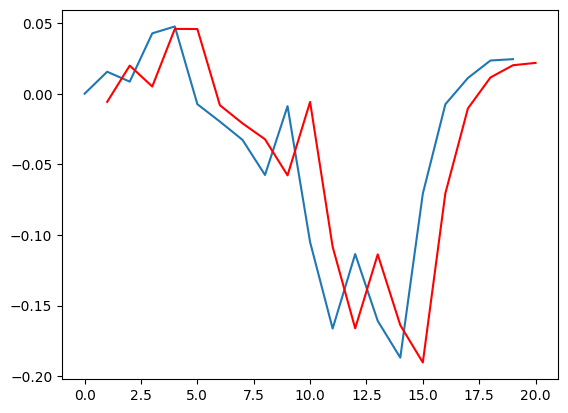

In [28]:
i = 0
seq = X[i:i+1].to(device)
pred, _ = model(seq)
print(seq.squeeze().numpy())
print(pred.squeeze().detach().cpu().numpy())
timesteps = np.arange(1, len(pred.squeeze().detach().cpu().numpy()) + 1)
plt.plot(seq.squeeze().numpy())
plt.plot(timesteps, pred.squeeze().detach().cpu().numpy(), color='red')
plt.show()